<a href="https://colab.research.google.com/github/KSharif/Python/blob/main/Homework_coding_KNN_and_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wine Data SVM


--- Dataset Information ---
Feature Names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Number of Features: 13
Total Samples: 178
Length of Training Data: 124
Length of Testing Data: 54

--- Sample Features from Each Class ---
 Class Label Class Name  alcohol  malic_acid  ash  alcalinity_of_ash  magnesium  total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity  hue  od280/od315_of_diluted_wines  proline Target Output
           0    class_0    14.23        1.71 2.43               15.6      127.0           2.80        3.06                  0.28             2.29             5.64 1.04                          3.92   1065.0       Class 0
           1    class_1    12.37        0.94 1.36               10.6       88.0           1.98        0.57                  0.28             0.42             1.95 1.

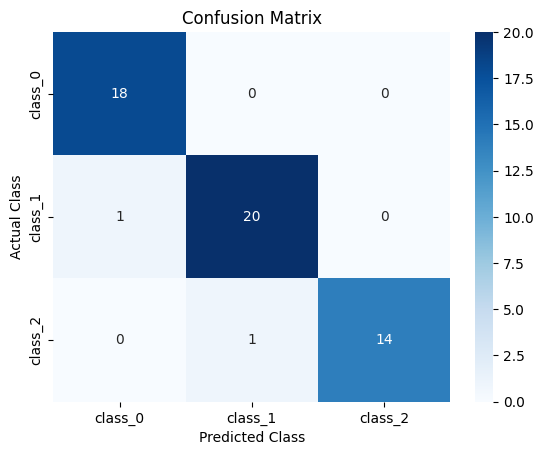

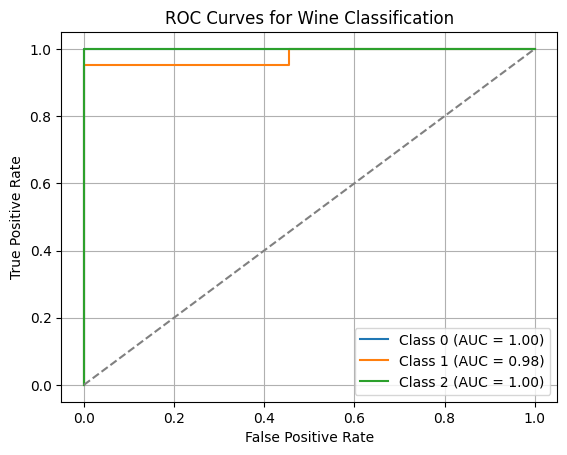

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler, label_binarize
import warnings
warnings.filterwarnings("ignore")

# Load wine dataset
wine_container = load_wine()
X = wine_container.data
y = wine_container.target
feature_names = wine_container.feature_names
target_names = wine_container.target_names

# Print dataset information
print("\n--- Dataset Information ---")
print("Feature Names:", feature_names)
print("Number of Features:", X.shape[1])
print("Total Samples:", len(X))

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y)

print("Length of Training Data:", len(x_train))
print("Length of Testing Data:", len(x_test))

# Initialize and train linear SVM
classifier_model = SVC(kernel='linear', probability=True, decision_function_shape='ovr')
classifier_model.fit(x_train, y_train)

# Predict on test data
test_predictions = classifier_model.predict(x_test)
decision_scores = classifier_model.decision_function(x_test)

# Display one sample from each class
unique_classes = np.unique(y)
sample_indices = [np.where(y == cls)[0][0] for cls in unique_classes]

df = pd.DataFrame(X[sample_indices], columns=feature_names)
df['Class Label'] = y[sample_indices]
df['Class Name'] = [target_names[label] for label in y[sample_indices]]
df['Target Output'] = ['Class ' + str(label) for label in y[sample_indices]]

# Reorder columns to show class info first and target output last
cols = ['Class Label', 'Class Name'] + feature_names + ['Target Output']
df = df[cols]

print("\n--- Sample Features from Each Class ---")
print(df.to_string(index=False))

# Compute and display test accuracy
test_accuracy = accuracy_score(y_test, test_predictions)
print("\nTest Accuracy:", round(test_accuracy, 4))

# Perform 5-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=0)
fold_scores = []

for fold_index, (train_index, test_index) in enumerate(kf.split(X_scaled)):
    model_fold = SVC(kernel='linear')
    model_fold.fit(X_scaled[train_index], y[train_index])
    fold_preds = model_fold.predict(X_scaled[test_index])
    fold_accuracy = accuracy_score(y[test_index], fold_preds)
    fold_scores.append(fold_accuracy)
    print(f"Fold {fold_index + 1} Accuracy:", round(fold_accuracy, 4))

print("Average Cross-Validation Accuracy:", round(np.mean(fold_scores), 4))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, test_predictions)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

# ROC Curve and AUC for each class
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
scores_bin = classifier_model.decision_function(x_test)

for class_index in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, class_index], scores_bin[:, class_index])
    auc_value = roc_auc_score(y_test_bin[:, class_index], scores_bin[:, class_index])
    plt.plot(fpr, tpr, label=f'Class {class_index} (AUC = {auc_value:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Wine Classification")
plt.legend()
plt.grid(True)
plt.show()


# Diabetes progression using KNN regression

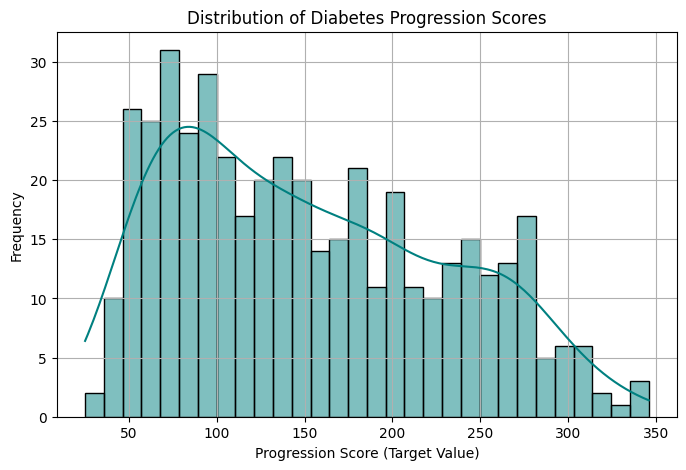

Sample Feature Vector:
age: -0.0891
sex: -0.0446
bmi: -0.0116
bp: -0.0367
s1: 0.0122
s2: 0.0250
s3: -0.0360
s4: 0.0343
s5: 0.0227
s6: -0.0094
Corresponding Target Value: 206.0

Mean Squared Error (MSE): 3222.12
Root Mean Squared Error (RMSE): 56.76


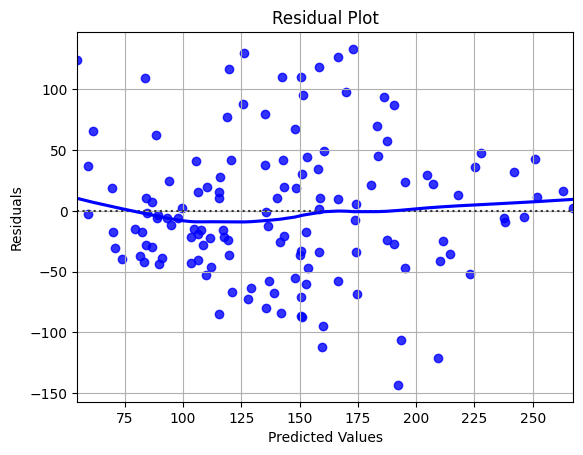

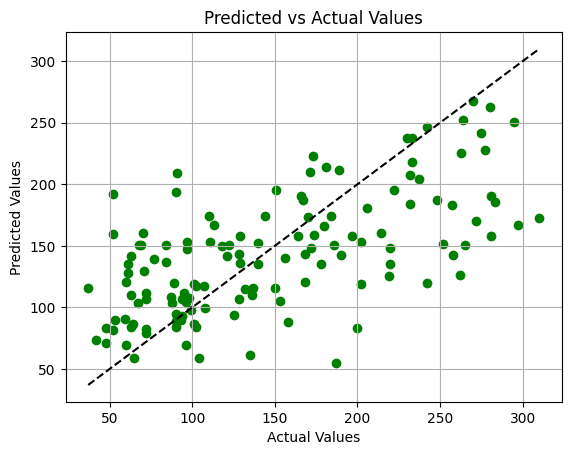

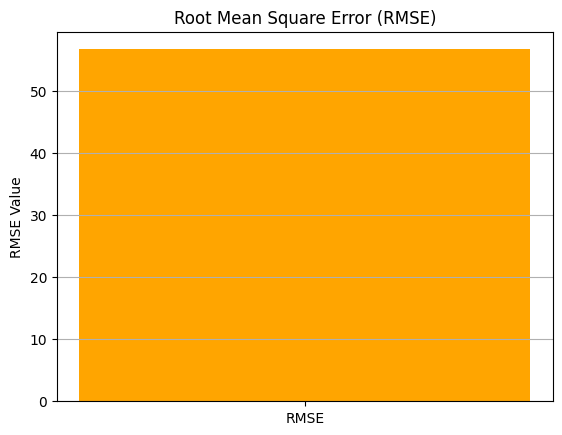

Fold 1 RMSE: 65.142
Fold 2 RMSE: 55.46
Fold 3 RMSE: 56.902
Fold 4 RMSE: 63.657
Fold 5 RMSE: 58.38
Average RMSE Across Folds: 59.908


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, KFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler


# Load dataset and show target distribution
data = load_diabetes()
X = data['data']
y = data['target']
feature_names = data['feature_names']

# 🔍 Distribution Plot of Diabetes Progression Scores
plt.figure(figsize=(8, 5))
sns.histplot(y, bins=30, kde=True, color='teal', edgecolor='black')
plt.title("Distribution of Diabetes Progression Scores")
plt.xlabel("Progression Score (Target Value)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


# Display features and target output for one sample
sample_idx = 3
print("Sample Feature Vector:")
for fname, fval in zip(feature_names, X[sample_idx]):
    print(f"{fname}: {fval:.4f}")
print("Corresponding Target Value:", y[sample_idx])


# Data Preprocessing
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42)


# Train KNN Regressor
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred = knn_model.predict(X_test)

# Compute Errors
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("\nMean Squared Error (MSE):", round(mse, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))


# Residual Plot
residuals = y_test - y_pred
plt.figure()
sns.residplot(x=y_pred, y=residuals, lowess=True, color='blue')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()


# Predicted vs Actual Plot
plt.figure()
plt.scatter(y_test, y_pred, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual Values")
plt.grid(True)
plt.show()


# RMSE Bar Plot
plt.figure()
plt.bar(['RMSE'], [rmse], color='orange')
plt.title("Root Mean Square Error (RMSE)")
plt.ylabel("RMSE Value")
plt.grid(axis='y')
plt.show()


# 5-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=0)
rmse_list = []

for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X_scaled)):
    fold_model = KNeighborsRegressor(n_neighbors=5)
    fold_model.fit(X_scaled[train_idx], y[train_idx])
    fold_preds = fold_model.predict(X_scaled[test_idx])
    fold_rmse = np.sqrt(mean_squared_error(y[test_idx], fold_preds))
    rmse_list.append(fold_rmse)
    print(f"Fold {fold_idx + 1} RMSE:", round(fold_rmse, 3))

print("Average RMSE Across Folds:", round(np.mean(rmse_list), 3))
